# SKKU 2024 Challenge #3: Heisenberg Spin Glass

In [116]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
import itertools
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

In [63]:
## utils.py
np.set_printoptions(linewidth=np.inf, precision=3)
backend = Aer.get_backend("aer_simulator")
backend2 = Aer.get_backend("statevector_simulator")

def MeasurementResultHandler(result:dict, num_qubits:int, num_shots:int):
	new_result = {}
	for i in range(2**num_qubits):
		temp = format(i,"#b")[2:]
		key = "".join(["0" for _ in range(num_qubits - len(temp))]) + temp
		new_result[key] = np.array(result[format(i,"#x")])/num_shots if result.get(format(i,"#x")) else np.array(0)
	return new_result

## Part 1

In [64]:
class H_sg():
    def __init__(self, coefficients1, coefficients2=None, num_qubits=4):
        self.num_qubits = num_qubits
        self.coefficients1 = coefficients1
        self.coefficients2 = coefficients2
        self.Pauli_X = np.array([
            [0,1],
            [1,0]
        ], dtype=np.complex128)
        self.Pauli_Y = np.array([
            [0,-1j],
            [1j,0]
        ], dtype=np.complex128)
        self.Pauli_Z = np.array([
            [1,0],
            [0,-1]
        ], dtype=np.complex128)
        self.I = np.eye(2, dtype=np.complex128)
        self.__reset__()
        self.eigenSpectrum()
    
    def _Kron(self, array):
        """
        Calculate the Kronecker product of a list of array.

        Args:
            tensors : list of np.array.
            [A_0, A_1, A_2, ..., A_N]
        Returns:
            prod: the Kronecker product of the input array.
            A_N ⊗ A_{N-1} ⊗ ... ⊗ A_1 ⊗ A_0
        """
        prod = np.array(1)
        if len(array) == 0:
            return prod
        else:
            for element in array:
                prod = np.kron(element, prod) 
            return prod
    
    def __reset__(self):
        qubit_idx = [idx for idx in range(self.num_qubits)]
        combinations = itertools.combinations(qubit_idx, 2)
        
        H_z = np.zeros([2**self.num_qubits, 2**self.num_qubits], dtype=np.complex128)
        if self.coefficients2 is not None:
            for i in range(self.num_qubits):
                temp = [self.I for _ in range(self.num_qubits)]
                temp[i] = self.Pauli_Z
                #print(self.coefficients2[i], i, temp)
                H_z += self.coefficients2[i]*self._Kron(temp)
        
        H_heisenberg = np.zeros([2**self.num_qubits, 2**self.num_qubits], dtype=np.complex128)
        for coefficient, pair_idx in zip(self.coefficients1, combinations):
            #print(coefficient, pair_idx)
            H_heisenberg += coefficient * self._H_ij(pair_idx)
            
        
        self.H_sg = H_heisenberg + H_z
        
    def _H_ij(self, qubit_idx):
        idx_1, idx_2 = list(qubit_idx)
        temp = [self.I for _ in range(self.num_qubits)]
        
        X = temp.copy(); Y = temp.copy(); Z = temp.copy()
        
        X[idx_1] = self.Pauli_X; X[idx_2] = self.Pauli_X
        Y[idx_1] = self.Pauli_Y; Y[idx_2] = self.Pauli_Y
        Z[idx_1] = self.Pauli_Z; Z[idx_2] = self.Pauli_Z
        
        return self._Kron(X) + self._Kron(Y) + self._Kron(Z)
    
    def eigenSpectrum(self):
        e_val, e_vec = np.linalg.eigh(self.H_sg)
        return e_val
    
    def plot_eigspectrum(self):
        fig, ax = plt.subplot()
        
        return 0

In [65]:
result = {}
for i in itertools.product([1,-1], repeat=6):
    temp = H_sg(i, [0,0,0,0]).eigenSpectrum()
    result[i] = temp

In [66]:
check_same = {}
eig_spectrum = {}
idx = 0
for key, item in result.items():
    isIn = False
    for new_key, new_item in check_same.items():
        if (np.abs(eig_spectrum[new_key] - item) < 1e-8 ).all():
            isIn = True
            check_same[new_key].append(key)
            break
        
    if isIn:
        continue
    else:
        idx += 1
        check_same[idx] = [key]
        eig_spectrum[idx] = item
        

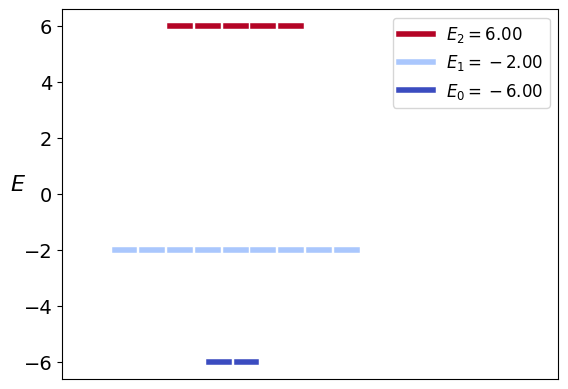

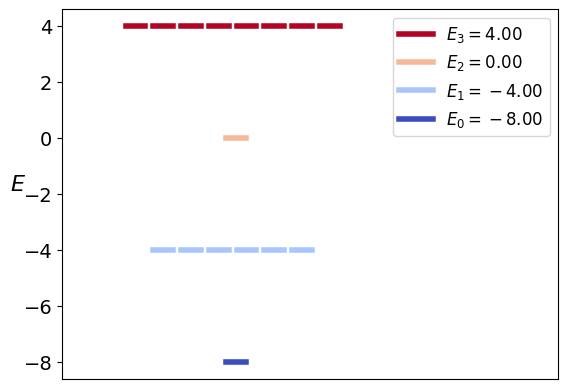

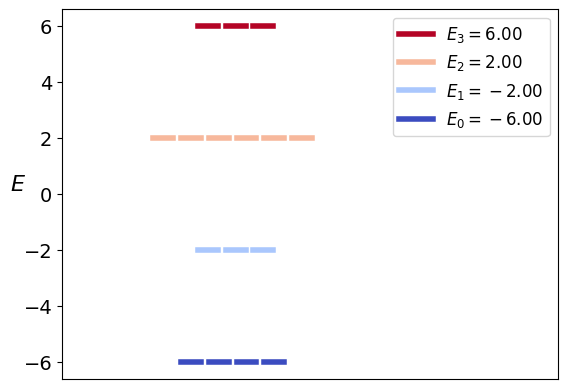

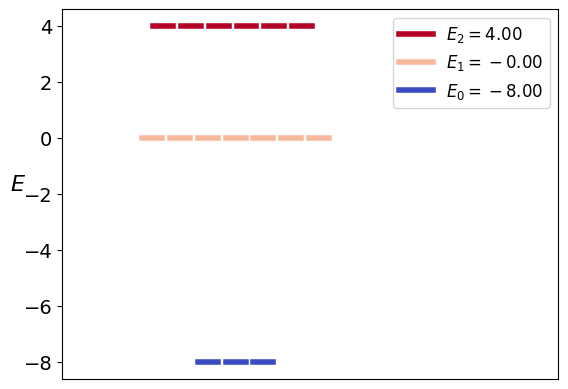

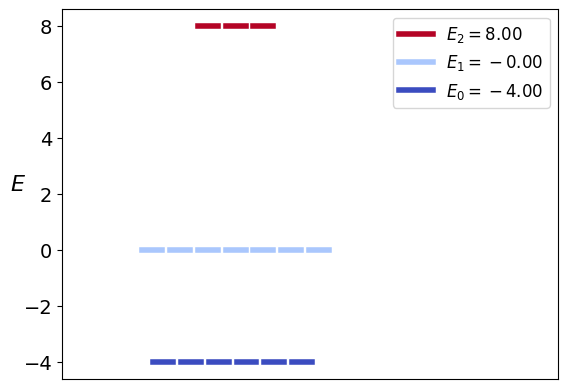

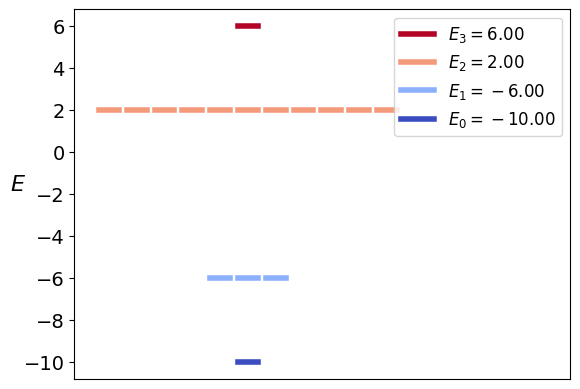

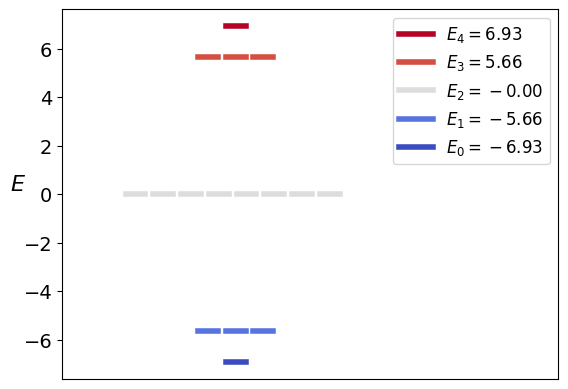

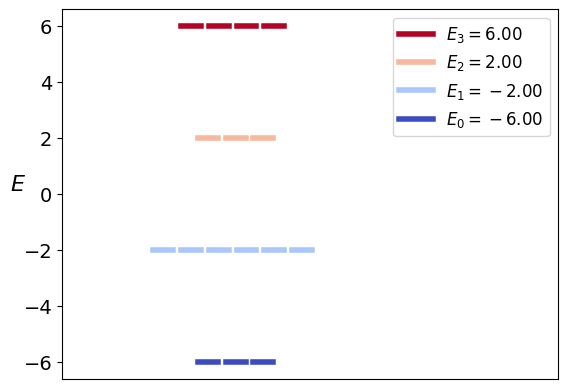

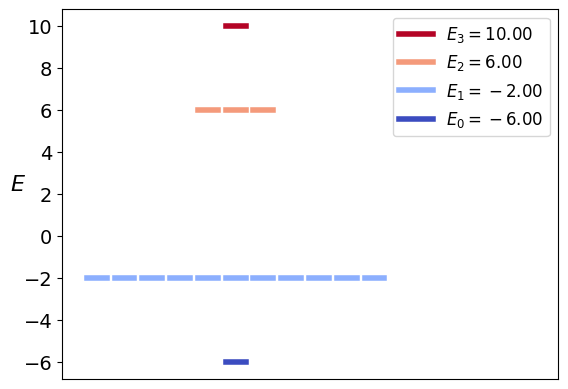

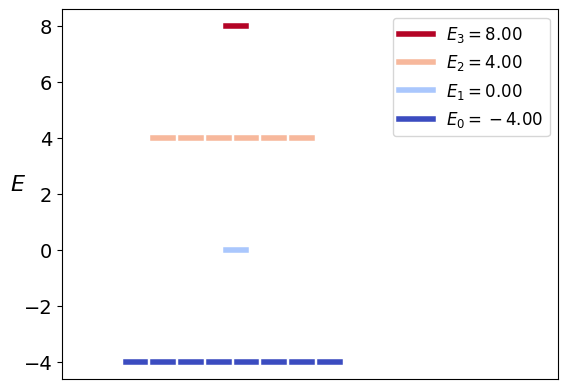

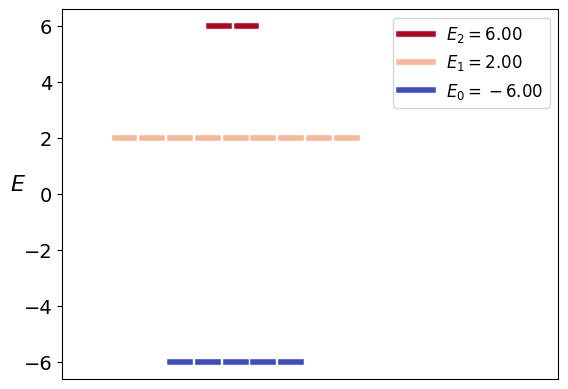

In [166]:
def plot_energy_level(energy_levels):
    fig, ax = plt.subplots()
    cmap = mpl.colormaps["coolwarm"]
    max_e = np.max(list(energy_levels.keys()))
    min_e = np.min(list(energy_levels.keys()))
    normalize = mpl.colors.Normalize(vmin=min_e, vmax=max_e)

    for idx, (energy, num) in enumerate(energy_levels.items()):
        unit_length = 0.04
        start = 0.35 - ((num // 2) * 1.4 + 0.5) * unit_length if num % 2 == 1 else 0.35 + (0.05 - (num // 2) * 1.4) * unit_length
        color = cmap(normalize(energy))
        
        label = "$E_{} = {:.2f}$".format(idx, energy)

        for i in range(num):
            if i == 0:  # Add label only for the first line at this energy level
                ax.axhline(energy, start, start + unit_length, color=color, label=label, linewidth=4.0)
            else:
                ax.axhline(energy, start, start + unit_length, color=color, linewidth=4.0)
            start += unit_length * 1.4
    handles, labels = ax.get_legend_handles_labels()
    
    ax.set_ylabel(r"$E$", rotation=0, fontsize=16)
    ax.tick_params(axis='y', which='major', labelsize=14)
    ax.legend(handles[::-1], labels[::-1], loc='upper right', fontsize=12)
    ax.get_xaxis().set_ticks([])
    
    #ax.grid()
    return fig, ax
idx = 1
for i in eig_spectrum.values():
    energy_level = {}
    for j in i:
        isIn = False
        for key, item in energy_level.items():
            if np.abs(key - j) < 1e-8:
                energy_level[key] += 1
                isIn = True
                break
        if not isIn:
            energy_level[j] = 1
            
    fig, ax = plot_energy_level(energy_level)
    fig.savefig("../report/figure/class_{}.pdf".format(idx)) 
    idx += 1


In [52]:
class AdiabaticSimulator(H_sg):
    def __init__(self, coefficients1, coefficients2, num_qubits=4) -> None:
        super().__init__(coefficients1, coefficients2, num_qubits)
        
        temp = [self.I for _ in range(self.num_qubits)]
        #temp = [self.Pauli_X for _ in range(self.num_qubits)]
        H_m = np.zeros([2**self.num_qubits, 2**self.num_qubits], dtype=np.complex128)
        for i in range(self.num_qubits):
            temp[i] = self.Pauli_X
            H_m -= self._Kron(temp)
        self.H_m = H_m
        
    def Propagator(self, s):
        return (1-s)*self.H_m + s*self.H_sg
    
    def EigenSpectrum(self):
        result = np.zeros([16,1000])
        time_step = np.linspace(0,1,1000)
        for i in range(len(time_step)):
            e_val = np.linalg.eigvalsh(self.Propagator(time_step[i]))
            result[:, i] = e_val
            
        return result
    
    def AdiabaticEvolution(self, tau, N):
        time_step = np.linspace(0, tau, N)
        dt = time_step[1] - time_step[0]
        
        ground_state = np.ones(2**self.num_qubits)/np.sqrt(2**self.num_qubits)
        for t in time_step:
            H = self.Propagator(t/tau)
            propagator = scipy.linalg.expm(-1j*dt*H)
            ground_state = propagator @ ground_state
        
        _, e_vec = np.linalg.eigh(self.H_sg)
        
        exact_ground = e_vec[:, 0]
        
        print(np.abs(exact_ground)) # TODO :  np.abs
        #prob = prob.conj() * prob
        
        return ground_state, exact_ground

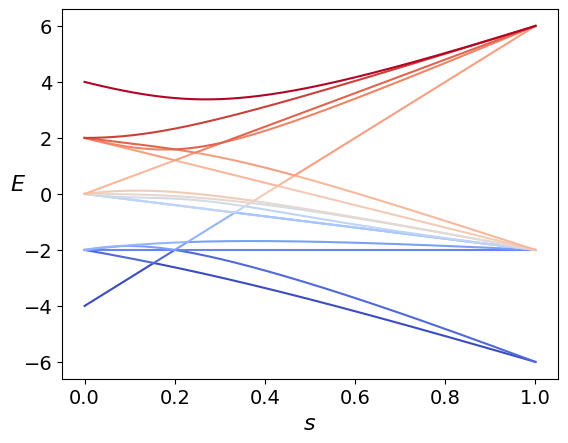

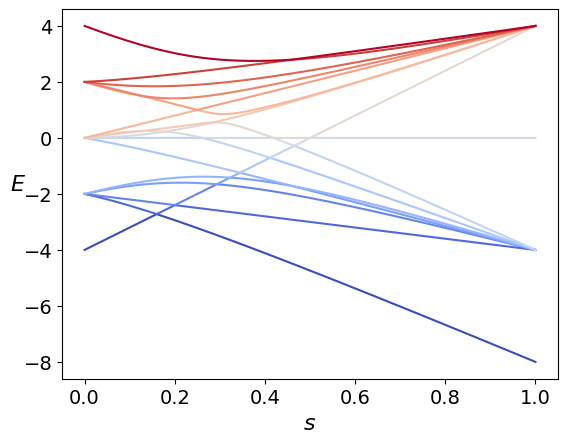

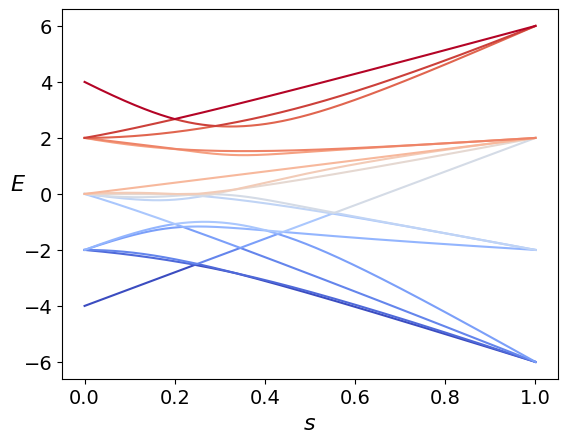

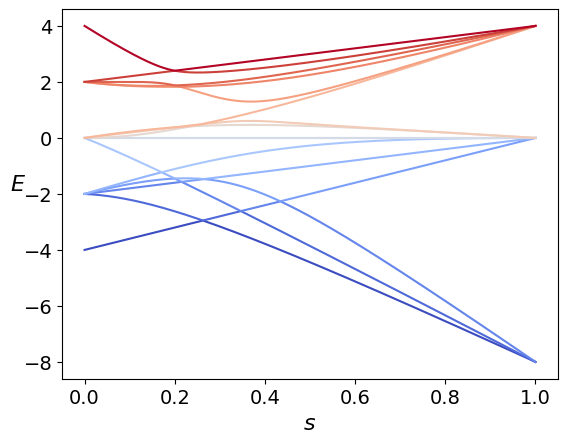

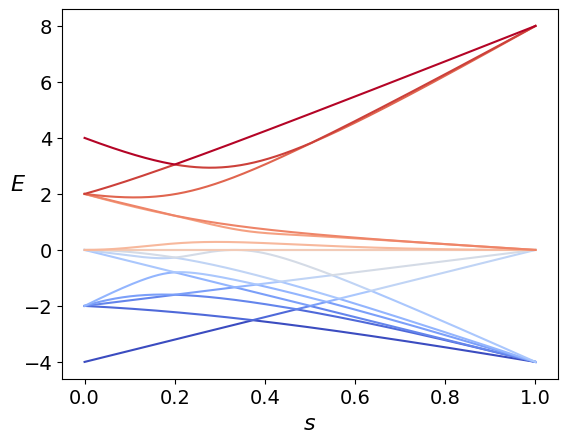

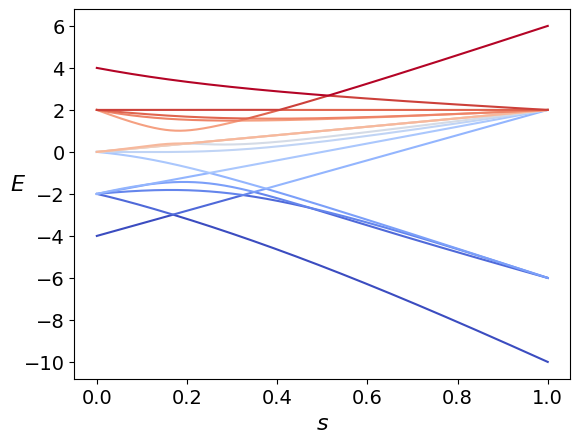

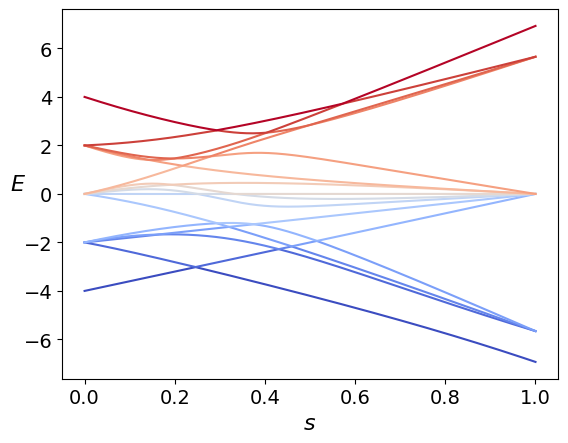

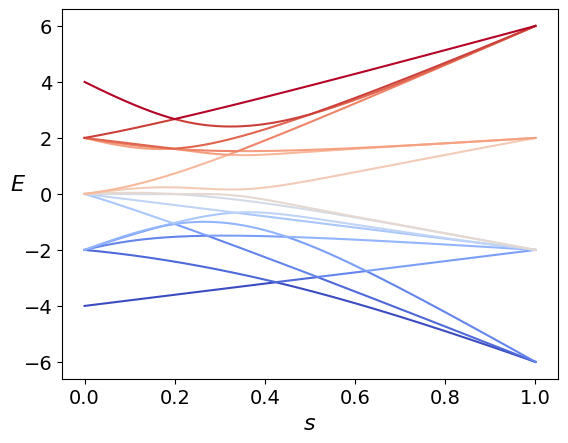

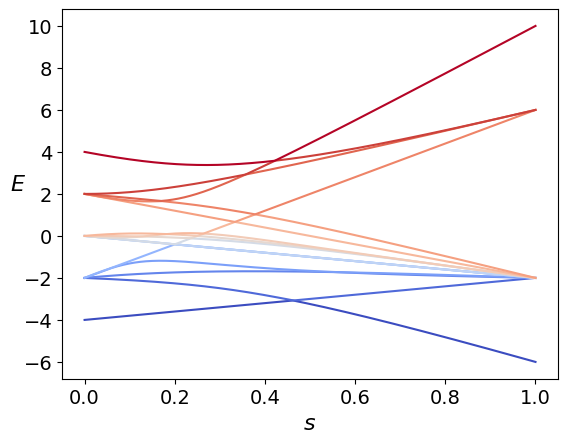

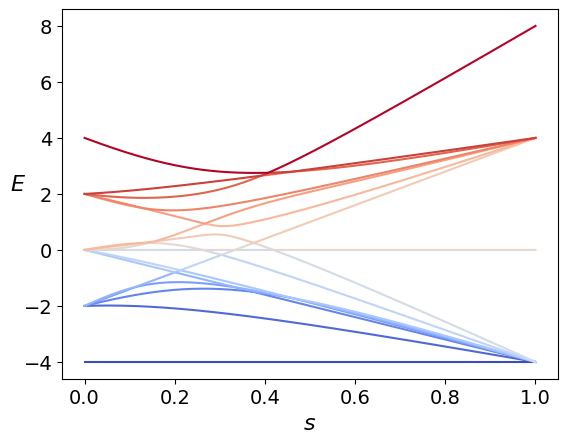

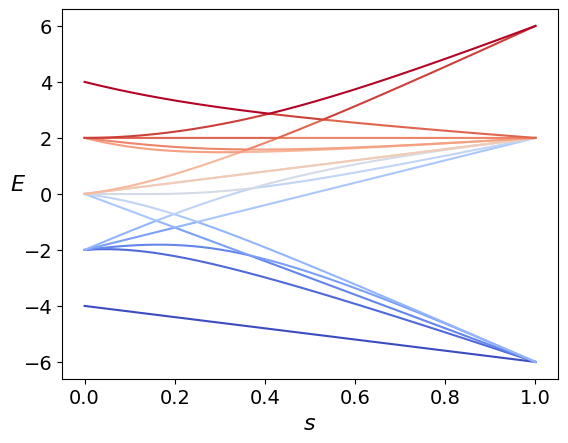

In [171]:
temp = {
    "class_1" : AdiabaticSimulator([1,1,1,1,1,1],[0,0,0,0]),
    "class_2" : AdiabaticSimulator([1,1,1,1,1,-1],[0,0,0,0]),
    "class_3" : AdiabaticSimulator([1,1,1,1,-1,-1],[0,0,0,0]),
    "class_4" : AdiabaticSimulator([1,1,1,-1,-1,-1],[0,0,0,0]),
    "class_5" : AdiabaticSimulator([1,1,-1,1,-1,-1],[0,0,0,0]),
    "class_6" : AdiabaticSimulator([1,1,-1,-1,1,1],[0,0,0,0]),
    "class_7" : AdiabaticSimulator([1,1,-1,-1,1,-1],[0,0,0,0]),
    "class_8" : AdiabaticSimulator([1,1,-1,-1,-1,-1],[0,0,0,0]),
    "class_9" : AdiabaticSimulator([1,-1,-1,-1,-1,1],[0,0,0,0]),
    "class_10": AdiabaticSimulator([1,-1,-1,-1,-1,-1],[0,0,0,0]),
    "class_11": AdiabaticSimulator([-1,-1,-1,-1,-1,-1],[0,0,0,0]),
}

def plot_eigenspectrum(result):
    fig, ax = plt.subplots()
    time_step = np.linspace(0,1,1000)    
    cmap = mpl.colormaps["coolwarm"]
    normalize = mpl.colors.Normalize(vmin=0, vmax=15)

    for i in range(result.shape[0]):
        color = cmap(normalize(i))
        ax.plot(time_step, result[i,:], c=color)
    
    ax.set_ylabel(r"$E$", rotation=0, fontsize=16)
    ax.set_xlabel(r"$s$", rotation=0, fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    #ax.legend()
    return fig, ax

for key, value in temp.items():
    result = value.EigenSpectrum()
    fig, ax = plot_eigenspectrum(result)
    fig.savefig("../report/figure/Eigenspectrum_" + key + ".pdf")

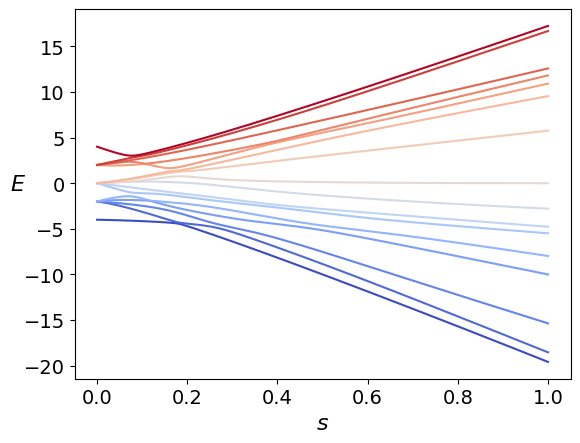

In [173]:
Heisenberg_sg = AdiabaticSimulator([-1,2,3,-2,-3,-4],[1,-1,2,3],4)
result = Heisenberg_sg.EigenSpectrum()
time_step = np.linspace(0,1,1000)
fig, ax = plot_eigenspectrum(result)
fig.savefig("../report/figure/Eigenspectrum_Heisenberg_sg.pdf")

In [46]:
ground_state, exact_ground = test.AdiabaticEvolution(3000,6000)
(ground_state.conj() * ground_state).real

[0.000e+00 4.282e-35 1.632e-33 4.977e-17 4.381e-32 2.434e-17 2.991e-17 3.488e-01 2.982e-32 2.868e-17 2.174e-17 3.074e-01 1.286e-17 7.958e-02 8.818e-01 0.000e+00]


array([6.797e-08, 4.798e-08, 6.402e-07, 1.078e-04, 5.752e-08, 1.361e-04, 6.746e-05, 1.216e-01, 1.277e-07, 1.339e-04, 8.467e-05, 9.470e-02, 5.467e-04, 6.228e-03, 7.764e-01, 3.196e-08])

In [168]:
class QAOASimulator(H_sg):
	def __init__(self, coefficients1, coefficients2, index, num_qubits=4) -> None:
		### Note : num_qubits should be fixed as 4
		super().__init__(coefficients1, coefficients2, num_qubits)
		
		self.index = index

		_, exact_ground = np.linalg.eigh(self.H_sg)
		self.exact_ground = exact_ground[:,0]
		self.target = np.abs(self.exact_ground)**2

	def _XY_mixer(self, pair, theta):
		i = pair[0]; j = pair[1]
		temp = [self.I for _ in range(self.num_qubits)]
		X = temp.copy(); Y = temp.copy()
		X[i] = self.Pauli_X; X[j] = self.Pauli_X
		Y[i] = self.Pauli_Y; Y[j] = self.Pauli_Y
		
		mixer = self._Kron(X) + self._Kron(Y)
		mixer = scipy.linalg.expm(-1j*theta/2*mixer)

		return mixer

	def ansatz(self, parameters):
		if len(self.index) != len(parameters):
			raise ValueError("Lengh should be matched")
		
		state = np.zeros(16, dtype=np.complex64)
		state[14] = 1

		operation = [self._XY_mixer(pair, parameter) for pair, parameter in zip(self.index, parameters)]
		for op in operation:
			state = op @ state
	
		return state

	def circuit(self, parameters):
		qc = qiskit.QuantumCircuit(self.num_qubits)
		for i in range(1,self.num_qubits):
			qc.x(i)
		for pair, parameter in zip(self.index, parameters):
			qc.rxx(parameter, pair[0], pair[1])
			qc.ryy(parameter, pair[0], pair[1])
		qc.rz(np.pi/2, 0)
		# TODO : adjust phase
		temp = self.ansatz(parameters)[[7,11,13,14]]
		print(temp)
		temp[0:3] *= (1j if temp[3] > 0 else -1j)
		temp = (temp > 0)
		for i in range(3):
			qc.rz(np.pi, 3-i) if temp[i] else None

		self.qc = qc
	
		return qc

	def cost(self, parameters):
		state = self.ansatz(parameters)
		amps = np.abs(state)**2
		cost = np.linalg.norm(amps - self.target)

		return cost

	def optimize(self):
		random_para = np.random.rand(3)*2*np.pi
		#initial_para = np.ones(3)
		res = scipy.optimize.minimize(test.cost, random_para, method="L-BFGS-B")
		#sol = res.x
		
		return res

	def _calculate_expectation(self, basis, i, j=None):
		"""
		Calculate the expectation value of <ψ|σ_z^i|ψ> or <ψ|σ_z^i σ_z^j|ψ>.

		Parameters:
			basis (string) : one of "x", "y", and "z"
			i (int): The qubit index for σ_z^i.
			j (int, optional): The qubit index for σ_z^j. If None, only σ_z^i is calculated.

		Returns:
			float: The calculated expectation value.
		"""
		expectation_value = 0

		measurement_outcome = self.measurement_outcome[basis]

		for bitstring, probability in measurement_outcome.items():
			# Extract bits for qubits i (and j if provided)
			bit_i = (int(bitstring, 2) >> i) & 1
			if j is not None:
				bit_j = (int(bitstring, 2) >> j) & 1
				# Determine sign based on parity of bit_i XOR bit_j
				sign = 1 if (bit_i ^ bit_j) == 0 else -1
			else:
				# Sign for single qubit based on whether bit_i is 0 or 1
				sign = 1 if bit_i == 0 else -1

			# Update expectation value with signed probability
			expectation_value += sign * probability

		return expectation_value

	def energy(self):
		energy = 0
		combinations = itertools.combinations([i for i in range(self.num_qubits)], 2)
		
		for coefficient, pair in zip(self.coefficients1, combinations):
			energy += coefficient * self._calculate_expectation("x", pair[0], pair[1])
			energy += coefficient * self._calculate_expectation("y", pair[0], pair[1])
			energy += coefficient * self._calculate_expectation("z", pair[0], pair[1])
		
		for idx, coefficient in enumerate(self.coefficients2):
			energy += coefficient * self._calculate_expectation("z", idx)
   
		return energy
		
	def perform_measure(self, num_shots=10000):
	
		qc_x = self.qc.copy()
		qc_y = self.qc.copy()
		qc_z = self.qc.copy()

		for i in range(self.num_qubits):
			qc_x.h(i)
			qc_y.s(i)
			qc_y.h(i)

		qc_x.measure_all()
		qc_y.measure_all()
		qc_z.measure_all()
	
		outcome_x = MeasurementResultHandler(backend.run(qc_x, shots=num_shots).result().data()["counts"], self.num_qubits, num_shots)
		outcome_y = MeasurementResultHandler(backend.run(qc_y, shots=num_shots).result().data()["counts"], self.num_qubits, num_shots)
		outcome_z = MeasurementResultHandler(backend.run(qc_z, shots=num_shots).result().data()["counts"], self.num_qubits, num_shots)

		self.measurement_outcome = {
			"x" : outcome_x,
			"y" : outcome_y,
			"z" : outcome_z,
		}
	
		return self.measurement_outcome

[ 0.   +0.349j  0.   +0.307j  0.   -0.08j  -0.882+0.j   ]


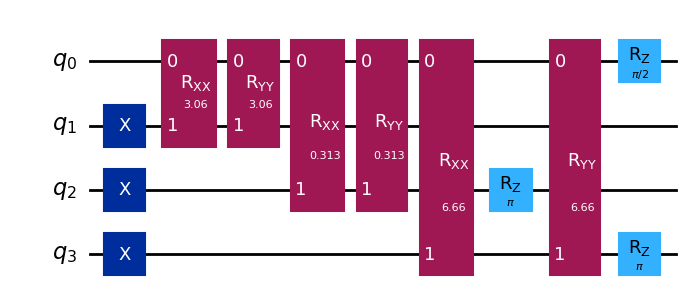

In [201]:
test = QAOASimulator([-1,2,3,-2,-3,-4],[1,-1,2,3],[(0,1),(0,2),(0,3)],4)
sol = test.optimize()
sol, sol.x % (2*np.pi)
test.circuit(sol.x).draw("mpl")

In [233]:
outcome = test.perform_measure(num_shots=10000000)
ground_energy =  test.energy()
ground_energy

np.float64(-19.5935288)

In [135]:
test.ansatz(sol.x)[[7,11,13,14]], test.exact_ground.real[[7,11,13,14]]

(array([0.   -0.349j, 0.   -0.307j, 0.   +0.08j , 0.882+0.j   ]),
 array([-0.349, -0.307, -0.08 ,  0.882]))

In [15]:
e, v = np.linalg.eigh(test.H_sg)

In [74]:
e.min()

np.float64(-19.58734233407557)